Create a quantum ciruit with 5 qubits.

Apply h-gate (Hadamard operator) to each qubit.

Apply z-gate ( Z  operator) to randomly picked qubits. (i.e.,  mycircuit.z(qreg[i]) )

Apply h-gate to each qubit.

Measure each qubit.

Execute your program 1000 times.

Compare the outcomes of the qubits affected by z-gates, and the outcomes of the qubits not affected by z-gates.

Does z-gate change the outcome?

Why?

In [1]:
!pip install qiskit
!pip install qiskit_aer
!pip install pylatexenc

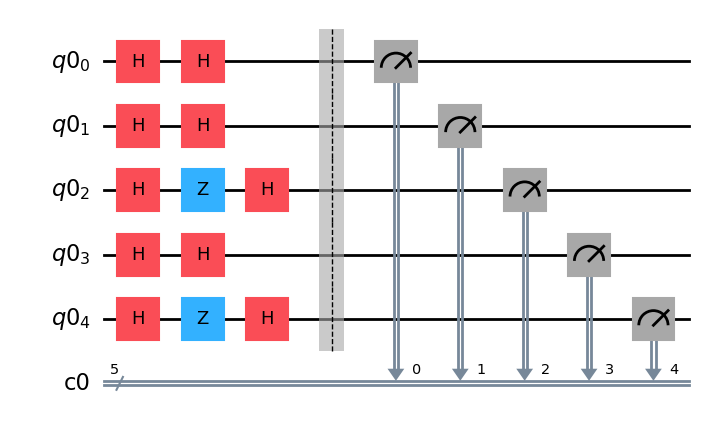

In [2]:
# import all necessary objects and methods for quantum circuits
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from qiskit_aer import Aer
# import randrange for random choices
from random import randrange

number_of_qubit = 5

# define a quantum register with 5 qubits
q =  QuantumRegister(number_of_qubit)

# define a classical register with 5 bits
c = ClassicalRegister(number_of_qubit)

# define our quantum circuit
qc = QuantumCircuit(q,c)

# apply h-gate to all qubits
for i in range(number_of_qubit):
    qc.h(q[i])

# apply z-gate to randomly picked qubits
for i in range(number_of_qubit):
    if randrange(2) == 0: # the qubit with index i is picked to apply z-gate
        qc.z(q[i])

# apply h-gate to all qubits
for i in range(number_of_qubit):
    qc.h(q[i])

qc.barrier()

# measure all qubits
qc.measure(q,c)

# draw the circuit
display(qc.draw(output='mpl'))

In [4]:
# execute the circuit 1000 times in the local simulator
simulator = Aer.get_backend('qasm_simulator')
job = simulator.run(qc,shots=1000)
counts = job.result().get_counts(qc)
print(counts)

{'10100': 1000}
